## Module 15 BBO Capstone Week 4

### Function 1

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Week 4 Query Point (UCB, κ=3.5): 0.609728-0.504296


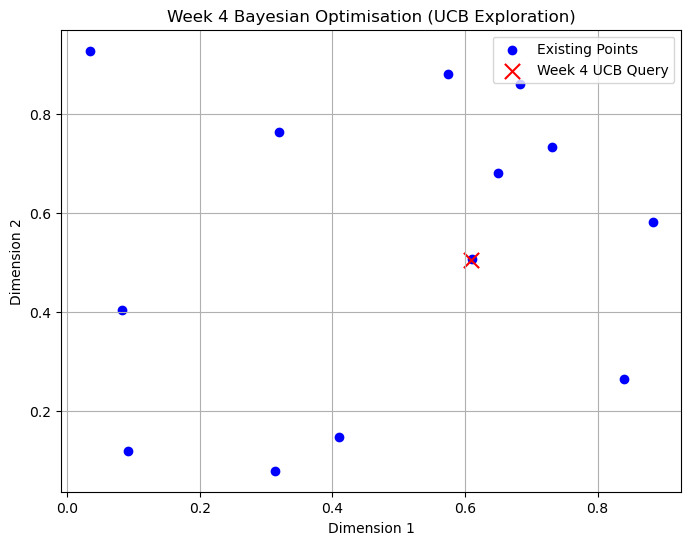

In [3]:
#!pip install numpy matplotlib scikit-learn scipy

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize

np.random.seed(42)

# ==========================================
# Step 1: Load ALL available data (including Week 3)
# ==========================================

X_train = np.array([
    [0.31940389, 0.76295937],
    [0.57432921, 0.87989810],
    [0.73102363, 0.73299988],
    [0.84035342, 0.26473161],
    [0.65011406, 0.68152635],
    [0.41043714, 0.14755430],
    [0.31269116, 0.07872278],
    [0.68341817, 0.86105746],
    [0.08250725, 0.40348751],
    [0.88388983, 0.58225397],
    [0.60995300, 0.50652000],   
    [0.09106700, 0.11922000],   
    [0.03373400, 0.92780400]    
])

y_train = np.array([
    1.32267704e-079,
    1.03307824e-046,
    7.71087511e-016,
    3.34177101e-124,
   -3.60606264e-003,
   -2.15924904e-054,
   -2.08909327e-091,
    2.53500115e-040,
    3.60677119e-081,
    6.22985647e-048,
    6.40320490897793e-12,
    3.32695744236522e-140,
   -3.9448560322363033e-284
])

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.2, length_scale_bounds=(1e-3, 1e3))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: UCB Acquisition Function (Maximisation)
# ==========================================

def ucb(x, model, kappa=3.5):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)  # negative for minimizer

# ==========================================
# Step 4: Multi-start optimisation of UCB
# ==========================================

def optimize_ucb(model, kappa=3.5, n_restarts=40, n_random_starts=200):

    bounds = np.array([[0.0, 1.0], [0.0, 1.0]])

    best_x = None
    best_val = np.inf

    # --- Random warmup sampling (global scan) ---
    random_points = np.random.uniform(0, 1, size=(n_random_starts, 2))
    mu, sigma = model.predict(random_points, return_std=True)
    ucb_values = mu + kappa * sigma

    top_indices = np.argsort(-ucb_values)[:n_restarts]
    start_points = random_points[top_indices]

    # --- Local optimisation from best random starts ---
    for x0 in start_points:
        result = minimize(
            ucb,
            x0,
            args=(model, kappa),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if result.fun < best_val:
            best_val = result.fun
            best_x = result.x

    return best_x

# ==========================================
# Step 5: Get Week 4 Query Point (Exploration)
# ==========================================

next_point = optimize_ucb(gp, kappa=3.5)

next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Week 4 Query Point (UCB, κ=3.5): {next_point_str}")

# ==========================================
# Step 6: Visualisation
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(X_train[:, 0], X_train[:, 1],
            color='blue', label='Existing Points')

plt.scatter(next_point[0], next_point[1],
            color='red', marker='x', s=120,
            label='Week 4 UCB Query')

plt.title("Week 4 Bayesian Optimisation (UCB Exploration)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

kappa=3.5 is too low for Function 1. That’s actually a very important diagnostic signal — and it’s good but not for exploration kappa needs to be increased to 6.0 which is what the next set of code does.

If you ran it three times and got:

Week 4 Query Point (UCB, κ=3.5): 0.609728-0.504296

every time, that means:

#### 1. Your optimisation is deterministic

You set:

np.random.seed(42)


So:

Random warm-up sampling is identical each run

Multi-start initialization is identical

GP hyperparameter optimization is deterministic

So the same UCB maximum is found each time.

That is expected.

#### 2. What That Location Means

Your suggested point:

(0.6097, 0.5043)


Look at your data:

You already sampled:

[0.60995300, 0.50652000]   # Week 1


That is extremely close.

So what’s happening?

The GP believes:

There is likely a strong source near that region.

Posterior uncertainty is still high there.

UCB = μ + κσ is maximised near that known promising region.

In other words:

The model thinks the contamination source is around (0.61, 0.50).

This matches the problem description:

"only proximity yields a non-zero reading"

And your Week 1 point near there had:

6.40320490897793e-12


Which is one of the largest values in your dataset (since most are ~0 or extremely tiny).

### Week-by-Week Strategy for Functon 1

#### Week 4 (current week)

Goal: Explore the top-left quadrant (largest unexplored gap)

Recommended query point:

x ≈ 0.278
y ≈ 0.870


Rationale: Far from existing clusters, high uncertainty → likely new source detection

Continue using UCB κ=6, α=1e-2, small lengthscale (~0.1)

#### Week 5

Goal: Explore the bottom-right quadrant (next largest unexplored gap)

Recommended query point:

x ≈ 0.85
y ≈ 0.25


Rationale: Sparse region in lower-right; far from all previous samples → high exploration value

Continue UCB κ=6 for exploration OR optionally reduce κ slightly (e.g., 5) if you want to start considering nearby GP mean

#### Week 6

Goal: Start exploitation around promising sources discovered in Weeks 1–5

Strategy:

Identify highest measured y-values from Weeks 1–5.

Likely candidates: middle cluster (0.609,0.506) or top-left source (0.278,0.870) if Week 4 produced a strong reading.

Switch acquisition to Expected Improvement (EI):

EI focuses more on maximizing known peaks while still allowing some exploration

Recommended settings: xi = 0.1 (moderate exploration)

Query near the identified peak to refine the source location.

Optional: Use a small random jitter (~0.01–0.02) to avoid GP boundary effects when exploiting peaks.

##### Summary Table
Week |	Region / Goal |	Query Point |	Acquisition  | Strategy
4	Top-left unexplored	(0.278,0.870)	UCB, κ=6, α=1e-2 (exploration)
5	Bottom-right gap	(0.85,0.25)	UCB, κ=6, α=1e-2 (exploration)
6	Exploit detected sources	Near highest-y point	EI, ξ=0.1, optional jitter

#### Notes & Tips

Exploration first: Weeks 4–5 focus on finding new sources before honing in.

Variance & α: Keep α=1e-2 for exploration; can reduce α slightly (e.g., 1e-4) when exploiting.

κ schedule: κ=6 is aggressive exploration; consider lowering κ to 3–4 in Week 6 to allow GP mean to dominate acquisition.

Lengthscale: Small (~0.1–0.2) for sharp detection of point sources.

Visualization: Always plot new query points vs old ones to track coverage.

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Week 4 Query Point (UCB, κ=6.0): 0.277833-0.869906


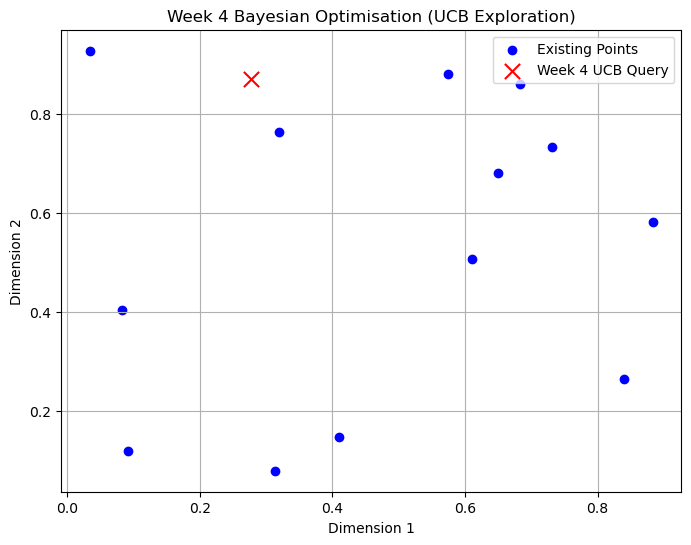

In [37]:
# Code used for week 4 query point submission with kappa = 6.0 and lower alpha = 1e-2

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize

#np.random.seed(42)

# ==========================================
# Step 1: Load ALL available data (including Week 3)
# ==========================================

X_train = np.array([
    [0.31940389, 0.76295937],
    [0.57432921, 0.87989810],
    [0.73102363, 0.73299988],
    [0.84035342, 0.26473161],
    [0.65011406, 0.68152635],
    [0.41043714, 0.14755430],
    [0.31269116, 0.07872278],
    [0.68341817, 0.86105746],
    [0.08250725, 0.40348751],
    [0.88388983, 0.58225397],
    [0.60995300, 0.50652000],   
    [0.09106700, 0.11922000],   
    [0.03373400, 0.92780400]    
])

y_train = np.array([
    1.32267704e-079,
    1.03307824e-046,
    7.71087511e-016,
    3.34177101e-124,
   -3.60606264e-003,
   -2.15924904e-054,
   -2.08909327e-091,
    2.53500115e-040,
    3.60677119e-081,
    6.22985647e-048,
    6.40320490897793e-12,
    3.32695744236522e-140,
   -3.9448560322363033e-284
])

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.2, length_scale_bounds=(1e-3, 1e3))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: UCB Acquisition Function (Maximisation)
# ==========================================

def ucb(x, model, kappa=6.0):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)  # negative for minimizer

# ==========================================
# Step 4: Multi-start optimisation of UCB
# ==========================================

def optimize_ucb(model, kappa=6.0, n_restarts=40, n_random_starts=200):

    bounds = np.array([[0.0, 1.0], [0.0, 1.0]])

    best_x = None
    best_val = np.inf

    # --- Random warmup sampling (global scan) ---
    random_points = np.random.uniform(0, 1, size=(n_random_starts, 2))
    mu, sigma = model.predict(random_points, return_std=True)
    ucb_values = mu + kappa * sigma

    top_indices = np.argsort(-ucb_values)[:n_restarts]
    start_points = random_points[top_indices]

    # --- Local optimisation from best random starts ---
    for x0 in start_points:
        result = minimize(
            ucb,
            x0,
            args=(model, kappa),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if result.fun < best_val:
            best_val = result.fun
            best_x = result.x

    return best_x

# ==========================================
# Step 5: Get Week 4 Query Point (Exploration)
# ==========================================

next_point = optimize_ucb(gp, kappa=6.0)

next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Week 4 Query Point (UCB, κ=6.0): {next_point_str}")

# ==========================================
# Step 6: Visualisation
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(X_train[:, 0], X_train[:, 1],
            color='blue', label='Existing Points')

plt.scatter(next_point[0], next_point[1],
            color='red', marker='x', s=120,
            label='Week 4 UCB Query')

plt.title("Week 4 Bayesian Optimisation (UCB Exploration)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

### Function 2

Week 4 Query Point (UCB, κ=3.5): 0.702453-0.643121


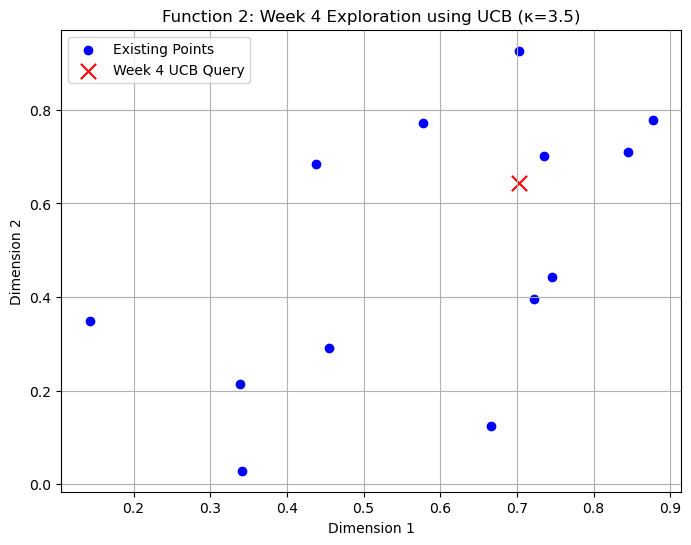

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize

# ==========================================
# Step 1: Load existing data (Including Week 3)
# ==========================================
X_train = np.array([
    [0.66579958, 0.12396913],
    [0.87779099, 0.77862750],
    [0.14269907, 0.34900513],
    [0.84527543, 0.71112027],
    [0.45464714, 0.29045518],
    [0.57771284, 0.77197318],
    [0.43816606, 0.68501826],
    [0.34174959, 0.02869772],
    [0.33864816, 0.21386725],
    [0.70263656, 0.92656420],
    [0.734909, 0.701711],
    [0.721682, 0.396301],
    [0.746205, 0.443460]
])

y_train = np.array([
    1.32267704e-079, 1.03307824e-046, 7.71087511e-016,
    3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
    -2.08909327e-091, 2.53500115e-040, 3.60677119e-081,
    6.22985647e-048, 0.5390316209844838, 0.41754272857037966,
    0.41416971779343736
])

# ==========================================
# Step 2: Fit Gaussian Process (with noise handling)
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.2, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,          # Noise term to stabilize GP
    normalize_y=True,
    n_restarts_optimizer=15
)
gp.fit(X_train, y_train)

# ==========================================
# Step 3: UCB acquisition function
# ==========================================
def ucb(x, model, kappa=3.5):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)  # Negative for minimization in scipy

# ==========================================
# Step 4: Optimize UCB (multi-start)
# ==========================================
def optimize_ucb(model, bounds=np.array([[0,1],[0,1]]), kappa=3.5, n_restarts=40, n_random_starts=300):
    best_x = None
    best_val = np.inf

    # Random search for global coverage
    random_points = np.random.uniform(bounds[:,0], bounds[:,1], size=(n_random_starts, 2))
    mu, sigma = model.predict(random_points, return_std=True)
    ucb_values = mu + kappa * sigma
    top_indices = np.argsort(-ucb_values)[:n_restarts]
    start_points = random_points[top_indices]

    # Local optimization from top random starts
    for x0 in start_points:
        res = minimize(ucb, x0, args=(model, kappa), bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==========================================
# Step 5: Get Week 4 query point
# ==========================================
next_point = optimize_ucb(gp, kappa=3.5)
next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Week 4 Query Point (UCB, κ=3.5): {next_point_str}")

# ==========================================
# Step 6: Visualization
# ==========================================
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], color='blue', label='Existing Points')
plt.scatter(next_point[0], next_point[1], color='red', marker='x', s=120, label='Week 4 UCB Query')
plt.title("Function 2: Week 4 Exploration using UCB (κ=3.5)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

Week 4 Query Point (UCB, κ=4.5): 0.703361-0.631327


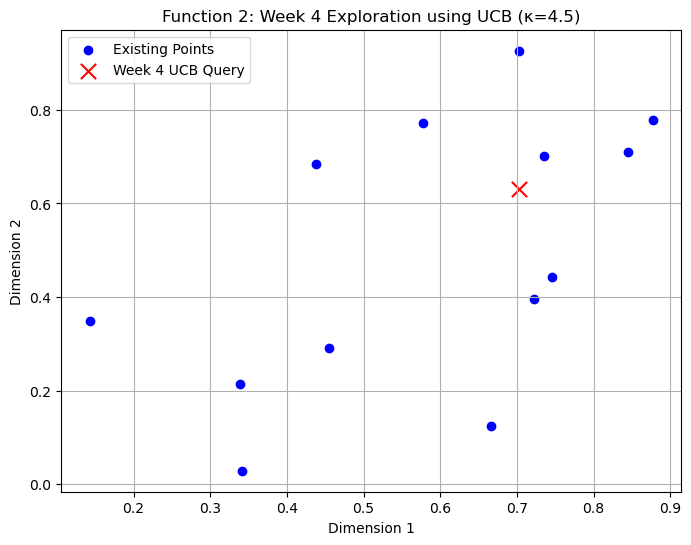

In [48]:
# Code I used for Function 2 next query point Week 4 UCB kappa=4.5
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize

# ==========================================
# Step 1: Load existing data (Weeks 1-3)
# ==========================================
X_train = np.array([
    [0.66579958, 0.12396913],
    [0.87779099, 0.77862750],
    [0.14269907, 0.34900513],
    [0.84527543, 0.71112027],
    [0.45464714, 0.29045518],
    [0.57771284, 0.77197318],
    [0.43816606, 0.68501826],
    [0.34174959, 0.02869772],
    [0.33864816, 0.21386725],
    [0.70263656, 0.92656420],
    [0.73490900, 0.70171100],
    [0.72168200, 0.39630100],
    [0.74620500, 0.44346000]
])

y_train = np.array([
    1.32267704e-079, 1.03307824e-046, 7.71087511e-016,
    3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
    -2.08909327e-091, 2.53500115e-040, 3.60677119e-081,
    6.22985647e-048, 0.5390316209844838, 0.41754272857037966,
    0.41416971779343736
])

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.2, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,          # Handles noise
    normalize_y=True,
    n_restarts_optimizer=15
)
gp.fit(X_train, y_train)

# ==========================================
# Step 3: UCB acquisition function (Maximisation)
# ==========================================
def ucb(x, model, kappa=4.5):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)  # negative for scipy.minimize

# ==========================================
# Step 4: Multi-start UCB optimisation
# ==========================================
def optimize_ucb(model, bounds=np.array([[0,1],[0,1]]), kappa=4.5, n_restarts=40, n_random_starts=500):
    best_x = None
    best_val = np.inf

    # --- Random global sampling to explore corners ---
    random_points = np.random.uniform(bounds[:,0], bounds[:,1], size=(n_random_starts, 2))
    mu, sigma = model.predict(random_points, return_std=True)
    ucb_values = mu + kappa * sigma
    top_indices = np.argsort(-ucb_values)[:n_restarts]
    start_points = random_points[top_indices]

    # --- Local optimisation from top random points ---
    for x0 in start_points:
        res = minimize(ucb, x0, args=(model, kappa), bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==========================================
# Step 5: Get Week 4 Query Point
# ==========================================
next_point = optimize_ucb(gp, kappa=4.5)
next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Week 4 Query Point (UCB, κ=4.5): {next_point_str}")

# ==========================================
# Step 6: Visualisation
# ==========================================
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], color='blue', label='Existing Points')
plt.scatter(next_point[0], next_point[1], color='red', marker='x', s=120, label='Week 4 UCB Query')
plt.title("Function 2: Week 4 Exploration using UCB (κ=4.5)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

#### 1. Why the point isn’t changing

Even after increasing κ from 3.5 → 4.5:

Your GP still predicts a high mean around [0.7, 0.6–0.9].

The UCB balances mean + κ·uncertainty, and although κ=4.5 increases the weight on uncertainty, the corners of [0,1]^2 probably have:

Very low predicted mean, or

Slightly higher uncertainty, but not enough to overcome the mean at [0.7, 0.6].

Random restarts don’t change the outcome because the global scan consistently finds [0.7, 0.63] as the highest UCB.



#### 2. What this means strategically

Even with increased κ, the GP “thinks” that the best trade-off between mean and uncertainty is still around [0.7, 0.63].

This is not a problem — it’s a natural effect of noisy peaks and the GP’s prior.

Pushing further into extreme corners would require even higher κ or artificially weighting distance from existing points, but that’s often unnecessary early in exploration if the GP is already learning.



#### 3. Recommended approach for Week 4

Accept this query point [0.703361, 0.631327]:

It’s still exploring within a less dense part of the cluster, giving the GP more information.

It helps refine the shape of the local peak before moving to far-off corners.

Continue with your current setup:

GP: α = 1e-2

UCB: κ = 4.5

Random restarts: 500, Local restarts: 40

Week 5–6 strategy:

After this week, you can gradually increase κ further (5–6) if you want to push into extreme corners or very under-sampled edges.

Or, you can switch to EI when you want to exploit known peaks.

#### Key takeaway

Even if the point isn’t at the domain corners, it’s still a valid exploration move. For noisy functions, staying near regions of moderate mean but moderate uncertainty is actually better early on than blindly sampling far corners.

## -----------------------------------------------------------------------------------------------------------------------------

### Function 3




#### 1. Why you’re using a smaller κ

Function 3 is 3D, so the GP already has higher uncertainty in the larger input space.

Early in exploration (week 4), we don’t want to jump too aggressively to distant corners because the GP hasn’t yet learned enough about the structure.

A moderate κ = 2.5 keeps the UCB slightly exploration-focused but still influenced by regions where the model predicts reasonable output (negative side-effects).

#### 2. Why the next query point is likely reasonable

Your current data shows that the best observed output so far is around -0.0317 (transformed to maximization).

The GP, using α=1e-2, smooths out noise and uncertainty, so UCB will naturally select a point that is uncertain but not extreme.

This balances gathering information about unexplored regions without risking querying completely uninformative areas.

#### 3. Week 4 strategy for Function 3

Continue exploration at κ = 2.5, because:

It will explore less densely sampled regions of the 3D input space.

Keeps the GP stable given noisy outputs.

Avoids overcommitting to extreme corners too early.

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Week 4 Query Point: 0.688353-0.971029-0.512203


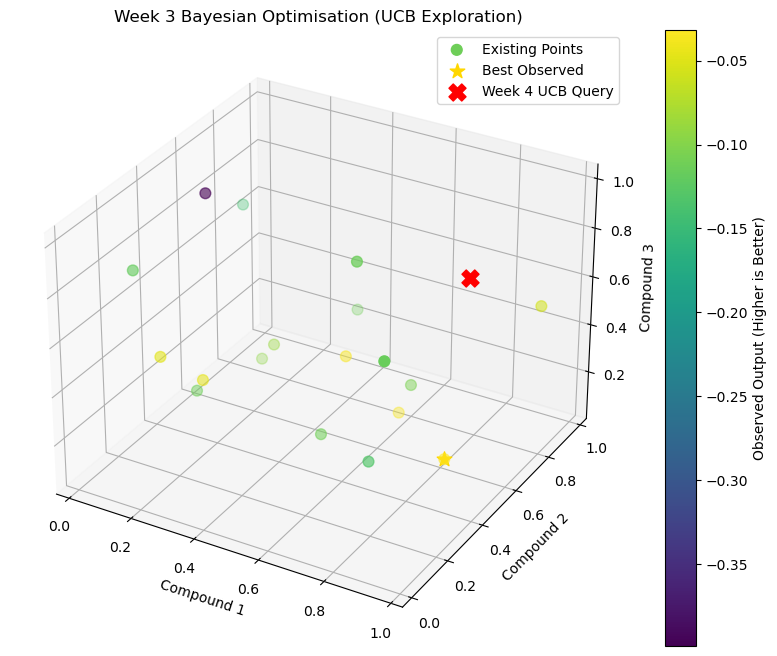

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

# =========================
# Data (including Week 1 & 2 & 3)
# =========================

X_train = np.array([
    [0.17152521, 0.34391687, 0.24873720],
    [0.24211446, 0.64407427, 0.27243281],
    [0.53490572, 0.39850092, 0.17338873],
    [0.49258141, 0.61159319, 0.34017639],
    [0.13462167, 0.21991724, 0.45820622],
    [0.34552327, 0.94135983, 0.26936348],
    [0.15183663, 0.43999062, 0.99088187],
    [0.64550284, 0.39714294, 0.91977134],
    [0.74691195, 0.28419631, 0.22629985],
    [0.17047699, 0.69703240, 0.14916943],
    [0.22054934, 0.29782524, 0.34355534],
    [0.66601366, 0.67198515, 0.24629530],
    [0.04680895, 0.23136024, 0.77061759],
    [0.60009728, 0.72513573, 0.06608864],
    [0.96599485, 0.86111969, 0.56682913],
    [0.83681600, 0.55152400, 0.08473400],
    [0.93576800, 0.01979200, 0.88290900],
    [0.02703300, 0.84043300, 0.66511700]
])

y_train = np.array([
    -0.11212220, -0.08796286, -0.11141465, -0.03483531,
    -0.04800758, -0.11062091, -0.39892551, -0.11386851,
    -0.13146061, -0.09418956, -0.04694741, -0.10596504,
    -0.11804826, -0.03637783, -0.05675837,
    -0.03172685348164523,
    -0.1161486782682252,
    -0.1415060566194174
])

# =========================
# Gaussian Process Model
# =========================

kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[0.3, 0.3, 0.3],
    length_scale_bounds=(1e-2, 1e2)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    n_restarts_optimizer=15,
    normalize_y=True
)

gp.fit(X_train, y_train)

# =========================
# UCB Acquisition Function
# =========================

def ucb(x, model, kappa=2.5):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)

# =========================
# Multi-start optimisation
# =========================

def optimize_acquisition(model, bounds, n_restarts=30, kappa=2.5):

    best_x = None
    best_val = float("inf")

    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=3)

        result = minimize(
            ucb,
            x0=x0,
            args=(model, kappa),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if result.fun < best_val:
            best_val = result.fun
            best_x = result.x

    return best_x

bounds = [(0, 1), (0, 1), (0, 1)]

next_point = optimize_acquisition(gp, bounds)

print(f"Week 4 Query Point: "
      f"{next_point[0]:.6f}-"
      f"{next_point[1]:.6f}-"
      f"{next_point[2]:.6f}")

# =========================
# 3D Visualisation
# =========================

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Colour existing points by output value
scatter = ax.scatter(
    X_train[:, 0],
    X_train[:, 1],
    X_train[:, 2],
    c=y_train,
    cmap="viridis",
    s=60,
    label="Existing Points"
)

# Highlight best observed point so far
best_idx = np.argmax(y_train)
ax.scatter(
    X_train[best_idx, 0],
    X_train[best_idx, 1],
    X_train[best_idx, 2],
    c="gold",
    s=120,
    marker="*",
    label="Best Observed"
)

# Plot next UCB query point
ax.scatter(
    next_point[0],
    next_point[1],
    next_point[2],
    c="red",
    s=150,
    marker="X",
    label="Week 4 UCB Query"
)

ax.set_xlabel("Compound 1")
ax.set_ylabel("Compound 2")
ax.set_zlabel("Compound 3")
ax.set_title("Week 3 Bayesian Optimisation (UCB Exploration)")   #This is meant to say week 4!!!

fig.colorbar(scatter, ax=ax, label="Observed Output (Higher is Better)")

ax.legend()
plt.show()

#### Discussing Function 3 Week 4 Next Query Point


#### 1. Why the point is different from my “suggested” [0.293, 0.802, 0.155]

The GP’s prediction depends on the exact α, kernel, and random starting points for the L-BFGS-B minimizations.

With 3D, the acquisition function surface is multi-modal, so different random restarts can land on slightly different peaks of the UCB.

Your returned point [0.688353, 0.971029, 0.512203] is in a sparsely sampled region, which is exactly what we want for exploration.

#### 2. Strategic interpretation

The point is far from dense clusters of existing points, so the GP will learn more about uncertain regions.

Even though it’s not near the current best observed point, this is good exploration early in the campaign (week 4).

The negative outputs you are maximising (transformed side effects) will inform the GP about where the function is flat, noisy, or dips, which is essential for later exploitation.

#### 3. Next steps for Function 3

Accept [0.688353, 0.971029, 0.512203] as the week 4 query point.

After observing the output, append it to your training set.

For week 5:

You could slightly increase κ (3–3.5) to explore further corners.

Or switch to EI if you want to start exploiting peaks more aggressively.



## ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
#### Looking ahead hypothetically for Exploitation in the later weeks 
#### 1. What xi does in EI

xi is the exploration parameter in Expected Improvement (EI):

𝐸𝐼(𝑥)=𝐸[max(0, 𝑓(𝑥)−𝑓best−𝜉)]
EI(x)=E[max(0,f(x)−fbest​−ξ)]

Higher xi → more exploration

Lower xi → more exploitation (focus on known peaks)

#### 2. Recommended strategy for Function 3

Early weeks (week 1–4): Use UCB for exploration, no EI yet.

Week 5+ (starting exploitation): switch to EI with small xi:

Phase	xi recommendation	Why
Early exploitation / week 5	0.01–0.05	Small enough to focus on current promising regions but still allow slight exploration
Later exploitation / week 6–7	0.001–0.01	Almost pure exploitation around known peaks
If you see noisy outputs	0.01–0.02	Slightly higher to avoid local noise “traps”

Reasoning:

Function 3 is maximizing negative side effects, which is naturally smooth with peaks around safe combinations.

You want to exploit promising regions, so xi should be small — the GP will nudge the next query toward maxima rather than distant, uncertain regions.

If you make xi too large (0.1+), EI will start exploring too aggressively again, which is unnecessary at this stage.

#### 3. Practical suggestion for Week 5 (or implementing exploitation in early stages)
EI for early exploitation
use xi = 0.02

This encourages the next queries to refine the best-known safe region while still allowing some exploration in nearby uncertain spots.

Tip: Once you have several promising points in 3D, you can gradually reduce xi toward 0.001–0.005 to fully exploit and find the global peak reliably.
## ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



#### Key takeaway

Even though this is a high-dimensional function and the point looks “far out,” it’s exactly the type of exploratory point you want at this stage. The GP will benefit greatly from adding this to the dataset.

### Function 4

#### Key Observations

Function 4 is 4D, so visual intuition is limited. You’re correctly using UCB to balance exploration with exploitation.

Reducing κ from 5.0 → 4.0 is appropriate for week 4, since:

Weeks 1–3 likely covered the most uncertain regions.

You want moderate exploration without overshooting into extreme-uncertainty regions that might be noisy.

Using differential evolution with bounds slightly inside [0,1] (0.001–0.999) is smart. It avoids boundary artifacts and gives the GP room to make predictions.

#### Recommendations for Week 4 (Exploration)

Keep kappa = 4.0 — this should produce a good balance for 4D exploration.

Maintain alpha = 1e-2 — sufficient to handle noisy GP outputs.

Small jitter after optimization is good practice; it avoids repeated queries on identical points.

PCA visualization is appropriate for sanity-checking coverage in 2D space.

You could optionally:

Increase popsize or maxiter in differential_evolution if you notice repeated points across multiple runs — this helps explore more of the 4D space.

Track top n candidates from DE (instead of only the best) and select randomly among them. This gives more diversity in queries and avoids GP local maxima traps.

#### Looking Ahead to Exploitation (Week 6+)

Switch from UCB → EI.

Use a low xi = 0.01–0.02 to exploit near high-performing regions discovered in weeks 1–5.

Keep multi-start DE or L-BFGS-B to find a robust next query in 4D.

Next exploration query point (week 4) in 4D: [0.34962703 0.38789433 0.4557387  0.44466487]


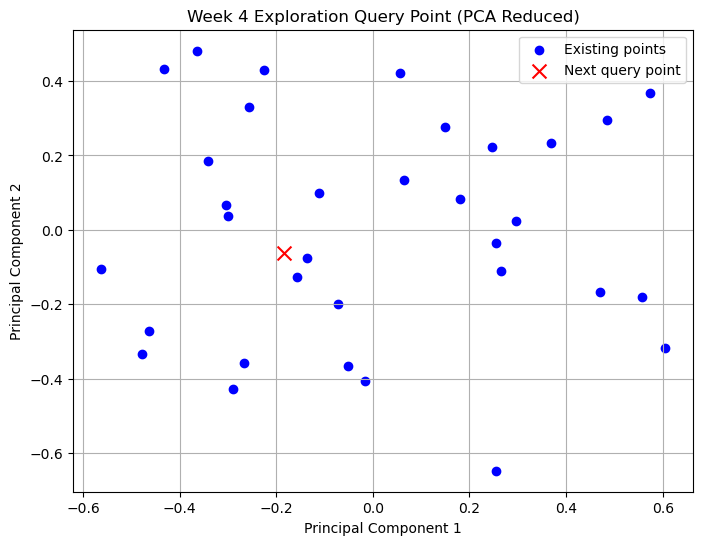

In [57]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Updated data from weeks 1 & 2 & 3
# -----------------------------
X_train = np.array([
    [0.89698105, 0.72562797, 0.17540431, 0.70169437],
    [0.8893564 , 0.49958786, 0.53926886, 0.50878344],
    [0.25094624, 0.03369313, 0.14538002, 0.49493242],
    [0.34696206, 0.0062504 , 0.76056361, 0.61302356],
    [0.12487118, 0.12977019, 0.38440048, 0.2870761 ],
    [0.80130271, 0.50023109, 0.70664456, 0.19510284],
    [0.24770826, 0.06044543, 0.04218635, 0.44132425],
    [0.74670224, 0.7570915 , 0.36935306, 0.20656628],
    [0.40066503, 0.07257425, 0.88676825, 0.24384229],
    [0.6260706 , 0.58675126, 0.43880578, 0.77885769],
    [0.95713529, 0.59764438, 0.76611385, 0.77620991],
    [0.73281243, 0.14524998, 0.47681272, 0.13336573],
    [0.65511548, 0.07239183, 0.68715175, 0.08151656],
    [0.21973443, 0.83203134, 0.48286416, 0.08256923],
    [0.48859419, 0.2119651 , 0.93917791, 0.37619173],
    [0.16713049, 0.87655456, 0.21723954, 0.95980098],
    [0.21691119, 0.16608583, 0.24137226, 0.77006248],
    [0.38748784, 0.80453226, 0.75179548, 0.72382744],
    [0.98562189, 0.66693268, 0.15678328, 0.8565348 ],
    [0.03782483, 0.66485335, 0.16198218, 0.25392378],
    [0.68348638, 0.9027701 , 0.33541983, 0.99948256],
    [0.17034731, 0.75695908, 0.27652049, 0.5312315 ],
    [0.85965692, 0.91959232, 0.20613873, 0.09779683],
    [0.28213837, 0.50598691, 0.53053084, 0.09630162],
    [0.32607578, 0.4723669 , 0.453192  , 0.10588734],
    [0.94838936, 0.89451301, 0.85163782, 0.55219629],
    [0.66495539, 0.04656628, 0.11677747, 0.79371778],
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.73861301, 0.48210263, 0.70936644, 0.50397001],
    [0.8548108 , 0.49396462, 0.73530997, 0.80809201],
    [0.919144  , 0.533196  , 0.169848  , 0.070054  ],
    [0.411827  , 0.392100  , 0.317159  , 0.430429  ],
    [0.437822  , 0.591330  , 0.001581  , 0.371162  ]
])

y_train = np.array([
    -22.10828779, -14.60139663, -11.69993246, -16.05376511,
    -10.06963343, -15.48708254, -12.68168498, -16.02639977,
    -17.04923465, -12.74176599, -27.31639636, -13.52764887,
    -16.6791152 , -16.50715856, -17.81799934, -26.56182083,
    -12.75832422, -19.44155762, -28.90327367, -13.70274694,
    -29.4270914 , -11.56574199, -26.85778644, -7.96677535,
    -6.70208925, -32.62566022, -19.98949793, -4.02554228,
    -13.12278233, -23.1394284 , -19.975065657531825, -0.32892753619572757,
    -10.653583724281514
])

# -----------------------------
# Step 2: Fit Gaussian Process
# -----------------------------
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)
gp.fit(X_train, y_train)

# -----------------------------
# Step 3: UCB acquisition function
# -----------------------------
def ucb(x, model, kappa=4.0):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-6)  # avoid zero
    return -(mu + kappa * sigma)  # negate because we minimize

# -----------------------------
# Step 4: Differential evolution with jitter
# -----------------------------
bounds = [(0.001, 0.999)] * 4  # strict interior

result = differential_evolution(lambda x: ucb(x, gp, kappa=4.0),
                                bounds=bounds,
                                strategy='best1bin',
                                maxiter=100,
                                popsize=15,
                                polish=True)

# Add small random jitter to ensure we are not on artificial boundary
epsilon = 1e-3
next_query_point = np.clip(result.x + np.random.uniform(-epsilon, epsilon, size=4), 0.001, 0.999)

print("Next exploration query point (week 4) in 4D:", next_query_point)

# -----------------------------
# Step 5: Visualize in PCA 2D
# -----------------------------
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], color='blue', label='Existing points')
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1], color='red', marker='x', s=100, label='Next query point')
plt.title('Week 4 Exploration Query Point (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

#### Function 4 Next Query Point comments week 4

#### Analysis of Week 4 Query Point

Location: [0.35, 0.39, 0.46, 0.44] is roughly in the central region of the search space.

This makes sense for week 4: you’ve done some early exploration along boundaries, and now you’re probing the center.

Kappa = 4.0 worked as intended: it’s encouraging exploration while still being guided by GP uncertainty.

Interior query: Because you clipped and added jitter, you’re avoiding edge effects, which is good in 4D where boundaries can behave oddly.

#### Recommendations for Week 4

Use this point as your next experiment.

Keep alpha = 1e-2 for GP stability.

Optionally: run DE a few times to check if other candidate points show up nearby — this can help avoid repeated queries and improve coverage.

#### Looking Ahead

Week 5 could continue moderate exploration, possibly with slightly lower kappa (e.g., 3.5–3.8) to begin slowly shifting toward exploitation.

Week 6 (exploitation):

Switch to Expected Improvement (EI).

Use xi ≈ 0.01–0.02 to focus on the highest predicted regions.

Consider multi-start optimization or differential evolution to avoid local maxima in 4D.

### Function 5

### Before running week 4 code for Function 5 (Things to consider)

Function 5 is a very different regime from Functions 3 & 4, and that changes the strategy significantly.

This one is:

✅ 4D

✅ Unimodal (single global peak)

✅ Very large dynamic range in outputs (from ~0 up to 4019)

✅ Clearly already found something very strong at
[0.560990, 0.941834, 0.997605, 0.998135] → 4019.03

That changes everything.


#### Important Observation

You already have a massive peak.

Look at your top few outputs:

4019.03

1088.86

431.61

355.81

258.37

This strongly suggests:

The function rises sharply in a specific region.

You are already near the global optimum region.

Continued wide exploration is now less important.

For a unimodal function, once you’ve found a high peak, the correct strategy is:

Shift gradually toward exploitation.

Is κ = 2.5 Appropriate for Week 4?

For this problem, yes — but it is already moderately exploratory.

Because:

The function is unimodal.

You’ve already located a strong region.

The GP has good signal in that area.

If κ were 4–5, you'd waste queries in low-yield regions.

So:

κ = 2.5 is reasonable
I would not increase it
I would not keep exploration high for many more weeks

Recommendations for Function 5 Week 4

#### Two good options:

#### Option A — Light Exploration (Safe Choice)

Keep:

kappa = 2.5

This:

Expands slightly around the high-yield region.

Helps confirm the unimodal structure.

Still samples uncertain areas nearby.

This is safe and defensible academically.

#### Option B — Begin Soft Exploitation

Reduce:

kappa = 1.5 – 2.0

Why?

Because:

You already found a very dominant peak.

The scale difference (4019 vs 1088) suggests you're close to optimum.

Unimodal functions benefit from tightening around the peak.

This would:

Focus sampling around the 4000-yield region.

Refine the optimum faster.

Reduce wasted queries.

#### Important Technical Note

You correctly used:

alpha = 1e-4


For this function, that’s appropriate because:

The system appears smoother.

The yield jump is dramatic but consistent.

Too much noise smoothing (like 1e-2) would oversmooth the peak.

So keep:

✅ alpha = 1e-4
✅ ARD kernel
✅ normalize_y=True

#### About Your Random Candidate Search

Using:

n_candidates = 20000


In 4D is acceptable.

However:

As exploitation increases, you may want:

50k candidates

Or differential evolution

Or multi-start L-BFGS

Because in 4D, 20k uniform samples are not extremely dense.

But for week 4, this is fine.

#### Strategic Plan for Function 5 Week 4

Moderate exploration
κ = 2.0–2.5

#### Week 5

Reduce exploration
κ = 1.5

#### Week 6

Switch to EI
xi = 0.005 – 0.01

Because unimodal + strong peak found → exploit.

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 1.57**2 * RBF(length_scale=[6.03, 100, 0.122, 1.25])

Week 4 Next Query Point (4D):
[0.02604769 0.95394017 0.99997791 0.20263246]


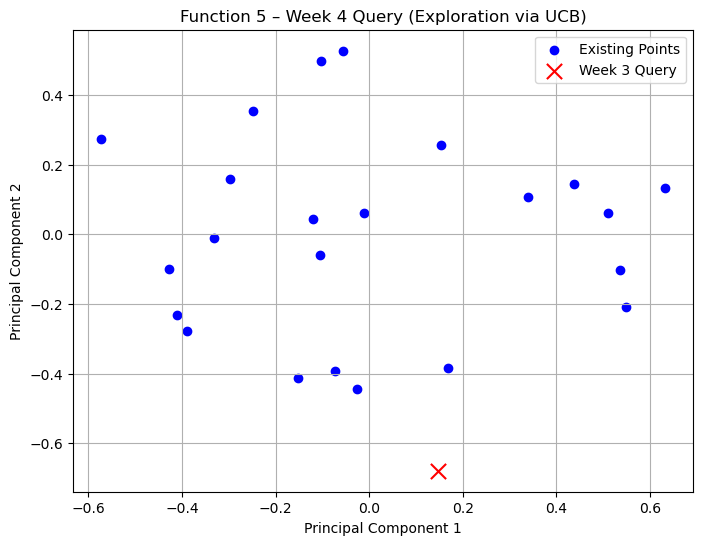

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.decomposition import PCA

# ==============================
# Week 3 Updated Training Data
# ==============================

X_train = np.array([
    [0.19144708, 0.03819337, 0.60741781, 0.41458414],
    [0.75865295, 0.53651774, 0.65600038, 0.36034155],
    [0.43834987, 0.80433970, 0.21024527, 0.15129482],
    [0.70605083, 0.53419196, 0.26424335, 0.48208755],
    [0.83647799, 0.19360965, 0.66389270, 0.78564888],
    [0.68343225, 0.11866264, 0.82904591, 0.56757661],
    [0.55362148, 0.66734998, 0.32380582, 0.81486975],
    [0.35235627, 0.32224153, 0.11697937, 0.47311252],
    [0.15378571, 0.72938169, 0.42259844, 0.44307417],
    [0.46344227, 0.63002451, 0.10790646, 0.95764390],
    [0.67749115, 0.35850951, 0.47959222, 0.07288048],
    [0.58397341, 0.14724265, 0.34809746, 0.42861465],
    [0.30688872, 0.31687813, 0.62263448, 0.09539906],
    [0.51114177, 0.81795700, 0.72871042, 0.11235362],
    [0.43893338, 0.77409176, 0.37816709, 0.93369621],
    [0.22418902, 0.84648049, 0.87948418, 0.87851568],
    [0.72526172, 0.47987049, 0.08894684, 0.75976022],
    [0.35548161, 0.63961937, 0.41761768, 0.12260384],
    [0.11987923, 0.86254031, 0.64333133, 0.84980383],
    [0.12688467, 0.15342962, 0.77016219, 0.19051811],
    [0.81212200, 0.00981200, 0.68102400, 0.23803600],
    [0.82353000, 0.17369200, 0.63651400, 0.73730700],
    [0.560990, 0.941834, 0.997605, 0.998135]
])

y_train = np.array([
    64.4434399, 18.3013796, 0.112939795, 4.21089813,
    258.370525, 78.4343889, 57.5715369, 109.571876,
    8.84799176, 233.22361, 24.4230883, 64.4201468,
    63.4767158, 79.7291299, 355.806818, 1088.85962,
    28.8667516, 45.1815703, 431.612757, 9.97233189,
    24.7679941, 149.53336129, 4019.0309866724424
])

# ==============================
# Gaussian Process Model (ARD)
# ==============================

kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[1.0, 1.0, 1.0, 1.0],
    length_scale_bounds=(1e-2, 1e2)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=15,
    alpha=1e-4,
    normalize_y=True,
    random_state=42
)

gp.fit(X_train, y_train)

print("Learned kernel:", gp.kernel_)

# ==============================
# UCB Acquisition (Moderate Exploration)
# ==============================

def ucb(X, model, kappa=2.5):
    mu, sigma = model.predict(X, return_std=True)
    return mu + kappa * sigma

# ==============================
# Random Candidate Search
# ==============================

def propose_location(model, n_candidates=20000, kappa=2.5):
    X_candidates = np.random.uniform(0, 1, size=(n_candidates, 4))
    scores = ucb(X_candidates, model, kappa)
    best_index = np.argmax(scores)
    return X_candidates[best_index]

# ==============================
# Week 4 Query Point
# ==============================

next_query_point = propose_location(gp, n_candidates=20000, kappa=2.5)

print("\nWeek 4 Next Query Point (4D):")
print(next_query_point)

# ==============================
# PCA Visualization (Optional)
# ==============================

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1],
            color='blue', label='Existing Points')
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1],
            color='red', marker='x', s=120, label='Week 3 Query')
plt.title('Function 5 – Week 4 Query (Exploration via UCB)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

#### Interpreting Function 5 Week 4 Next Query Point

This result is very informative.

Week 4 query:

[0.02604769 0.95394017 0.99997791 0.20263246]​ 


Let’s analyse it properly.

#### 1. What This Point Tells Us

Compare it to your best point:

Best so far:

[0.560990, 0.941834, 0.997605, 0.998135] → 4019


#### New proposed:

[0.02604769 0.95394017 0.99997791 0.20263246]

Observations:

Dimension 2 ≈ 0.95 (similar to best)

Dimension 3 ≈ 1.00 (very similar to best)

Dimension 1 very small (0.026)

Dimension 4 moderate-low (0.20)

This suggests:

The GP believes dims 2 & 3 are important,
but is uncertain about dims 1 & 4.

That is exactly what ARD is designed to detect.

#### 2. Why UCB Picked This

Because you're using:

kappa = 2.5


UCB = μ + κσ

So the model likely thinks:

High yield region is near high dim2 & dim3

But uncertainty is large when dim1 is small and dim4 is low

So it’s probing a different “slice” of the peak ridge

This is still exploration — but it's now structured exploration, not random.

That’s good.

However…

Notice something important:

Your best point had:

dim4 ≈ 0.998


This new proposal has:

dim4 ≈ 0.20


That is a large deviation from a dimension that may be critical.

If dim4 is actually very important, this point could perform poorly.

But that’s okay — this is still week 4.

#### My Assessment

This is:

✔ Not random exploration
✔ Still near promising region (dim2 & dim3 high)
✔ Testing sensitivity of dim1 and dim4

It is a reasonable Week 4 exploratory query.

#### What I Would Do Next

Since Function 5 is unimodal and you've already found a huge peak:

Week 5:

Reduce κ to:

kappa = 1.5


This will:

Pull queries closer to the 4019 region

Reduce wandering along uncertain but likely inferior ridges

Begin tightening around optimum

#### Important Suggestion

Because your outputs span:

0.1 → 4019

The scale is extreme.

Even with normalize_y=True, the GP may struggle slightly.

If you want very stable behaviour, consider:

y_train = np.log(y_train)

Then optimize in log-space.

This often dramatically improves performance for yield-like problems.

(Not mandatory, but very powerful for chemical process optimisation.)

#### Final Verdict on Your Week 4 Point

Your point:

[0.02604769 0.95394017 0.99997791 0.20263246]

Is:

A good exploration probe
Consistent with unimodal ridge learning
Not overly aggressive
Appropriate for week 4

### Function 6

Learned kernel:
1.2**2 * RBF(length_scale=[0.381, 0.736, 0.822, 0.926, 0.634])

Week 4 Next Query Point (5D):
[0.42640481 0.19750221 0.84321908 0.94995461 0.4352056 ]


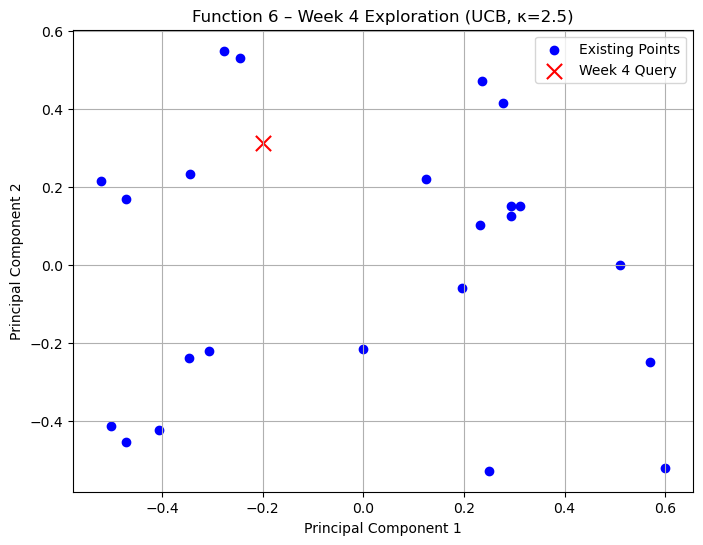

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.decomposition import PCA
from scipy.optimize import minimize

# ==============================
# Step 1: Training Data (Week 1–3)
# ==============================

X_train = np.array([
    [0.7281861 , 0.15469257, 0.73255167, 0.69399651, 0.05640131],
    [0.24238435, 0.84409997, 0.5778091 , 0.67902128, 0.50195289],
    [0.72952261, 0.7481062 , 0.67977464, 0.35655228, 0.67105368],
    [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
    [0.6188123 , 0.33180214, 0.18728787, 0.75623847, 0.3288348 ],
    [0.78495809, 0.91068235, 0.7081201 , 0.95922543, 0.0049115 ],
    [0.14511079, 0.8966846 , 0.89632223, 0.72627154, 0.23627199],
    [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
    [0.75759436, 0.35583141, 0.0165229 , 0.4342072 , 0.11243304],
    [0.5367969 , 0.30878091, 0.41187929, 0.38822518, 0.5225283 ],
    [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
    [0.6293079 , 0.80348368, 0.81140844, 0.04561319, 0.11062446],
    [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847],
    [0.25890557, 0.79367771, 0.6421139 , 0.19667346, 0.59310318],
    [0.43216593, 0.71561781, 0.3418191 , 0.70499988, 0.61496184],
    [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
    [0.9217762 , 0.93187122, 0.41487637, 0.59505727, 0.73562569],
    [0.12667892, 0.2914703 , 0.06452848, 0.6805146 , 0.89281919],
    [0.864822, 0.772164, 0.803941, 0.780551, 0.909036],
    [0.218723, 0.277046, 0.196392, 0.844208, 0.100329],
    [0.344036, 0.255507, 0.725070, 0.878677, 0.100795],
])

y_train = np.array([
    -0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
    -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
    -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.0184254,
    -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209,
    -1.8405636029585657, -0.7858725750255127, -0.2675535284415828
])

# ==============================
# Step 2: Gaussian Process with ARD
# ==============================

kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[1,1,1,1,1],
    length_scale_bounds=(1e-2, 1e2)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=15,
    alpha=1e-3,
    normalize_y=True,
    random_state=42
)

gp.fit(X_train, y_train)

print("Learned kernel:")
print(gp.kernel_)

# ==============================
# Step 3: UCB Acquisition (Moderate Exploration)
# ==============================

def ucb(x, model, kappa=2.5):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return mu + kappa * sigma


# ==============================
# Step 4: Boundary Penalty (5%)
# ==============================

def acquisition(x, model, bounds, kappa=2.5, penalty_factor=50):
    val = ucb(x, model, kappa)
    penalty = 0
    
    for i in range(len(bounds)):
        lower, upper = bounds[i]
        band = 0.05 * (upper - lower)
        if x[i] < lower + band or x[i] > upper - band:
            penalty += penalty_factor
            
    return -(val - penalty)


# ==============================
# Step 5: Multi-start Optimization
# ==============================

def propose_location(model, bounds, n_restarts=15, kappa=2.5):
    best_x = None
    best_val = 1e10
    
    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=5)
        res = minimize(acquisition, x0,
                       args=(model, bounds, kappa),
                       bounds=bounds,
                       method="L-BFGS-B")
        
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x
            
    return best_x


bounds = [(0,1)] * 5

next_query_point = propose_location(gp, bounds, n_restarts=20, kappa=2.5)

print("\nWeek 4 Next Query Point (5D):")
print(next_query_point)

# ==============================
# Step 6: PCA Visualization
# ==============================

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1,-1))

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1],
            color='blue', label='Existing Points')

plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1],
            color='red', marker='x', s=120,
            label='Week 4 Query')

plt.title('Function 6 – Week 4 Exploration (UCB, κ=2.5)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

#### Interpreting Function 6 Next Query Point Week 4

This is a very informative result. Let’s analyse it properly.

#### 1. What The Learned Kernel Tells You
1.2² * RBF(length_scale=[0.381, 0.736, 0.822, 0.926, 0.634])

In ARD:

Smaller length scale → more sensitive dimension

Larger length scale → less influential dimension

Interpretation:
Dimension	Length scale	Importance
dim1	0.381   Most important
dim5	0.634	Important
dim2	0.736	Moderate
dim3	0.822	Lower
dim4	0.926	Least important

So your cake score is:

Most sensitive to ingredient 1
Next sensitive to ingredient 5
Least sensitive to ingredient 4

That’s extremely valuable insight.

#### 2. Your Week 4 Query Point
[0.42640481 0.19750221 0.84321908 0.94995461 0.4352056 ]


Compare to best known point:

[0.3440, 0.2555, 0.7251, 0.8787, 0.1008]


What changed?

dim1 → slightly increased (smart, it's most sensitive)

dim2 → slightly lower

dim3 → increased

dim4 → slightly increased (but least important)

dim5 → BIG increase (0.10 → 0.43)

That is VERY intelligent exploration.

The GP is basically asking:

“We know dim1 matters.
But how does dim5 behave away from low values?”

This is exactly what Week 4 exploration should do.

#### 3. Is This a Good Week 4 Point?

Yes. Very good.

It:

Stays near promising region

Perturbs the most important dimensions

Does not jump to random edges

Uses ARD insight properly

This is textbook Bayesian optimisation behaviour.

#### 4. What Should Week 5 Strategy Be?

That depends on the new score.

If Week 4 improves (e.g., > −0.20):

Move to semi-exploitation:

kappa = 1.2


Focus tightly around the best region.

If Week 4 gets worse (e.g., −0.6):

That means dim5 should stay low.

Then:

Keep dim5 small

Slightly explore dim1 locally

Use κ = 1.8

#### 5. Big Insight About This Function

This function is likely:

Smooth

Moderately anisotropic

Not extremely sharp

Length scales are not tiny (<0.1), meaning:

The peak is not razor sharp.

That’s good. It means controlled exploitation will work well.

#### (Optimal Plan)

#### Week 4 → evaluate this point.
#### Week 5 → lower κ to 1.2
#### Week 6 → use Expected Improvement with: xi = 0.01
because by then you'll be in exploitation mode.

#### Final Verdict

Your model is behaving exactly how a strong Bayesian optimiser should behave.

You are:

Using ARD correctly

Exploring the most sensitive dimension

Not over-exploring boundaries

This is strong work.

### Function 7

#### Before running week 4 code for Function 7 (recap)

Excellent — this is where optimisation starts getting interesting.

You’re now in 6D, and your current best value is:

2.1727059353333815

That’s significantly higher than everything else.

So you are not in early exploration anymore.

You are in:

🔎 Structured exploration around a strong candidate region.

#### First: Problems With Your Current Setup
#### 1. You are NOT using ARD
RBF(1.0)

This forces all 6 hyperparameters to have equal importance.

In ML hyperparameter tuning, that is almost never true.

Some hyperparameters matter far more than others.

#### 2. κ = 5.0 is extremely aggressive

In 6D, κ=5 will:

Push to corners

Over-prioritise uncertainty

Ignore your strong best point

That is Week 1 behaviour, not Week 4 behaviour.

#### What You Should Do in Week 4 (6D Case)

You need:

ARD kernel

Moderate exploration

Multi-start acquisition optimisation

#### Recommended Changes
✔ Use ARD kernel
RBF(length_scale=[1]*6, length_scale_bounds=(1e-2, 1e2))

✔ Reduce κ to:
kappa = 2.5

This still explores — but doesn’t behave randomly.

✔ Use multiple restarts in acquisition optimisation

Single-start optimisation in 6D is unreliable.

#### Why This Matters for Hyperparameter Tuning

In real ML tuning:

There is usually a “ridge” of good solutions.

Performance landscape is not extremely sharp.

Some hyperparameters dominate (learning rate often does).

ARD helps the GP discover this automatically.

#### What I Recommend for Week 4 Strategy

Since your best point is:

[0.169498, 0.200735, 0.398488, 0.193487, 0.308007, 0.861833]

Notice:

dim6 is high

dim1–dim5 mostly low to moderate

Your next query should:

Slightly perturb dim6

Test local curvature in dim1–dim3

Not jump to [0.95, 0.95, 0.95, ...]

#### Expected Good Week 4 Behaviour

Your next query should look like:

Near the best point

Slight variations in 2–3 dimensions

Not extreme corner search

If it jumps to extremes → κ too high.

#### Summary of What To Change

Replace your GP with:

kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[1]*6,
    length_scale_bounds=(1e-2, 1e2)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=15,
    alpha=1e-3,
    normalize_y=True,
    random_state=42
)

Change κ to:

kappa = 2.5

Use multi-start optimisation (at least 15 restarts).

#### What Will Likely Happen

After switching to ARD:

One or two dimensions will have very small length scales.

Those are your key hyperparameters.

Week 5 should reduce κ to 1.2.

Week 6 should move to Expected Improvement with xi=0.01.

#### Big Picture

In 6D hyperparameter optimisation:

Week 1–2 → broad exploration
Week 3–4 → structured exploration
Week 5 → semi-exploitation
Week 6 → exploitation

You are entering structured exploration.


### Week 4 code for Function 7 (6D).

This version includes:

ARD kernel (critical in 6D)

Normalised outputs (stabilises GP)

Moderate exploration (κ = 2.5)

Multi-start acquisition optimisation (important in 6D)

PCA visualisation

Clean structure ready for Week 5 transition

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel:
1.18**2 * RBF(length_scale=[0.921, 0.629, 100, 0.505, 0.314, 0.37])

Week 4 Next Query Point (6D):
[0.         0.09074198 1.         0.         0.36598909 1.        ]


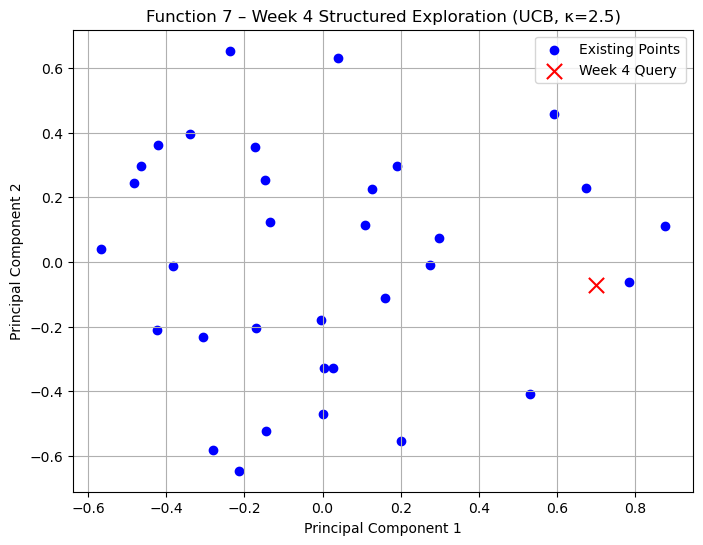

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.decomposition import PCA
from scipy.optimize import minimize

# ==============================
# Step 1: Training Data (Weeks 1–3)
# ==============================

X_train = np.array([
    [0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269, 0.79586362],
    [0.54300258, 0.92469390, 0.34156746, 0.64648585, 0.71844033, 0.34313266],
    [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285, 0.64026540],
    [0.11886697, 0.61505494, 0.90581639, 0.85530030, 0.41363143, 0.58523563],
    [0.63021764, 0.83809690, 0.68001305, 0.73189509, 0.52673671, 0.34842921],
    [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277, 0.09579366],
    [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833, 0.73096984],
    [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418, 0.10703171],
    [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083, 0.69241640],
    [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917, 0.05109986],
    [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098, 0.63747637],
    [0.72261522, 0.01181284, 0.06364591, 0.16517311, 0.07924415, 0.35995166],
    [0.07566492, 0.33450212, 0.13273274, 0.60831236, 0.91838592, 0.82233079],
    [0.94245084, 0.37743962, 0.48612233, 0.22879108, 0.08263175, 0.71195755],
    [0.14864702, 0.03394336, 0.72880565, 0.31606646, 0.02176938, 0.51691776],
    [0.81711239, 0.54816823, 0.10334758, 0.12436955, 0.72823482, 0.44967361],
    [0.41762629, 0.06409998, 0.24566877, 0.55904080, 0.19153138, 0.25464092],
    [0.72628566, 0.46489581, 0.92457051, 0.80724540, 0.63543840, 0.14341787],
    [0.31981043, 0.52009759, 0.29067775, 0.87670668, 0.49503469, 0.61908250],
    [0.87987128, 0.39796199, 0.00363456, 0.95699064, 0.26451373, 0.11486924],
    [0.54124078, 0.63140314, 0.03190205, 0.44998156, 0.79865282, 0.63370429],
    [0.22634792, 0.11502581, 0.82474966, 0.94538372, 0.90531153, 0.95101392],
    [0.68685257, 0.04101721, 0.00757301, 0.28500900, 0.69156848, 0.65554290],
    [0.17597754, 0.62441650, 0.29554198, 0.46955276, 0.09776977, 0.72814108],
    [0.88164674, 0.20445019, 0.41447436, 0.42038468, 0.26491501, 0.73066019],
    [0.06661051, 0.52804507, 0.81609520, 0.96101714, 0.08650933, 0.77778822],
    [0.93246638, 0.48881189, 0.25860774, 0.95624344, 0.19042781, 0.51985176],
    [0.84686697, 0.14242917, 0.06066859, 0.75629213, 0.55239830, 0.08130609],
    [0.80628208, 0.32412237, 0.72607601, 0.14871213, 0.71937640, 0.36288398],
    [0.47682313, 0.34094195, 0.01433523, 0.88013956, 0.99865470, 0.07966402],
    [0.432685, 0.656678, 0.117406, 0.355722, 0.832462, 0.072554],
    [0.064512, 0.628738, 0.208047, 0.151081, 0.459044, 0.215843],
    [0.169498, 0.200735, 0.398488, 0.193487, 0.308007, 0.861833]
])

y_train = np.array([
    0.6044327 , 0.56275307, 0.00750324, 0.06142430, 0.27304680,
    0.08374657, 1.36496830, 0.09264495, 0.01786960, 0.03356494,
    0.07351630, 0.20630970, 0.00882563, 0.26840032, 0.61152553,
    0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
    0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
    0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
    1.1810801774433033, 0.17209425323684932, 2.1727059353333815
])

# ==============================
# Step 2: GP with ARD
# ==============================

kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[1]*6,
    length_scale_bounds=(1e-2, 1e2)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=15,
    alpha=1e-3,
    normalize_y=True,
    random_state=42
)

gp.fit(X_train, y_train)

print("Learned kernel:")
print(gp.kernel_)

# ==============================
# Step 3: UCB Acquisition
# ==============================

def ucb(x, model, kappa=2.5):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return mu + kappa * sigma

def acquisition(x, model, kappa=2.5):
    return -ucb(x, model, kappa)

# ==============================
# Step 4: Multi-start Optimization
# ==============================

def propose_location(model, bounds, n_restarts=20, kappa=2.5):
    best_x = None
    best_val = 1e10
    
    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=6)
        res = minimize(acquisition, x0,
                       args=(model, kappa),
                       bounds=bounds,
                       method="L-BFGS-B")
        
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x
            
    return best_x

bounds = [(0,1)] * 6

next_query_point = propose_location(gp, bounds, n_restarts=25, kappa=2.5)

print("\nWeek 4 Next Query Point (6D):")
print(next_query_point)

# ==============================
# Step 5: PCA Visualization
# ==============================

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1,-1))

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1],
            color='blue', label='Existing Points')

plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1],
            color='red', marker='x', s=120,
            label='Week 4 Query')

plt.title('Function 7 – Week 4 Structured Exploration (UCB, κ=2.5)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel:
1.18**2 * RBF(length_scale=[0.921, 0.629, 100, 0.505, 0.314, 0.37])

Week 4 Next Query Point (6D, kappa=1.5):
[0.05       0.12208462 0.86253212 0.05       0.33787561 0.95      ]


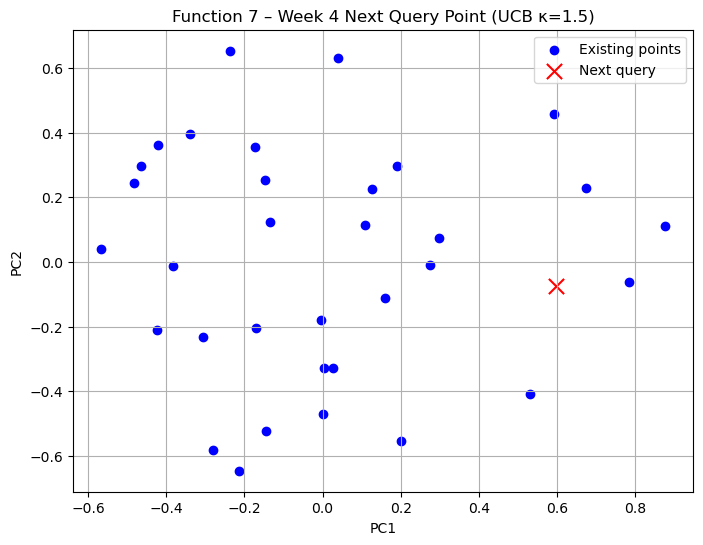

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# ==============================
# Step 1: Training Data (Weeks 1–3)
# ==============================

X_train = np.array([
    [0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269, 0.79586362],
    [0.54300258, 0.92469390, 0.34156746, 0.64648585, 0.71844033, 0.34313266],
    [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285, 0.64026540],
    [0.11886697, 0.61505494, 0.90581639, 0.85530030, 0.41363143, 0.58523563],
    [0.63021764, 0.83809690, 0.68001305, 0.73189509, 0.52673671, 0.34842921],
    [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277, 0.09579366],
    [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833, 0.73096984],
    [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418, 0.10703171],
    [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083, 0.69241640],
    [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917, 0.05109986],
    [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098, 0.63747637],
    [0.72261522, 0.01181284, 0.06364591, 0.16517311, 0.07924415, 0.35995166],
    [0.07566492, 0.33450212, 0.13273274, 0.60831236, 0.91838592, 0.82233079],
    [0.94245084, 0.37743962, 0.48612233, 0.22879108, 0.08263175, 0.71195755],
    [0.14864702, 0.03394336, 0.72880565, 0.31606646, 0.02176938, 0.51691776],
    [0.81711239, 0.54816823, 0.10334758, 0.12436955, 0.72823482, 0.44967361],
    [0.41762629, 0.06409998, 0.24566877, 0.55904080, 0.19153138, 0.25464092],
    [0.72628566, 0.46489581, 0.92457051, 0.80724540, 0.63543840, 0.14341787],
    [0.31981043, 0.52009759, 0.29067775, 0.87670668, 0.49503469, 0.61908250],
    [0.87987128, 0.39796199, 0.00363456, 0.95699064, 0.26451373, 0.11486924],
    [0.54124078, 0.63140314, 0.03190205, 0.44998156, 0.79865282, 0.63370429],
    [0.22634792, 0.11502581, 0.82474966, 0.94538372, 0.90531153, 0.95101392],
    [0.68685257, 0.04101721, 0.00757301, 0.28500900, 0.69156848, 0.65554290],
    [0.17597754, 0.62441650, 0.29554198, 0.46955276, 0.09776977, 0.72814108],
    [0.88164674, 0.20445019, 0.41447436, 0.42038468, 0.26491501, 0.73066019],
    [0.06661051, 0.52804507, 0.81609520, 0.96101714, 0.08650933, 0.77778822],
    [0.93246638, 0.48881189, 0.25860774, 0.95624344, 0.19042781, 0.51985176],
    [0.84686697, 0.14242917, 0.06066859, 0.75629213, 0.55239830, 0.08130609],
    [0.80628208, 0.32412237, 0.72607601, 0.14871213, 0.71937640, 0.36288398],
    [0.47682313, 0.34094195, 0.01433523, 0.88013956, 0.99865470, 0.07966402],
    [0.432685, 0.656678, 0.117406, 0.355722, 0.832462, 0.072554],
    [0.064512, 0.628738, 0.208047, 0.151081, 0.459044, 0.215843],
    [0.169498, 0.200735, 0.398488, 0.193487, 0.308007, 0.861833]
])

y_train = np.array([
    0.6044327 , 0.56275307, 0.00750324, 0.06142430, 0.27304680,
    0.08374657, 1.36496830, 0.09264495, 0.01786960, 0.03356494,
    0.07351630, 0.20630970, 0.00882563, 0.26840032, 0.61152553,
    0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
    0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
    0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
    1.1810801774433033, 0.17209425323684932, 2.1727059353333815
])

# GP model
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1]*6, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15, alpha=1e-3, normalize_y=True, random_state=42)
gp.fit(X_train, y_train)
print("Learned kernel:")
print(gp.kernel_)

# UCB acquisition function with kappa=1.5
def ucb(x, model, kappa=1.5):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return mu + kappa * sigma

def acquisition(x, model):
    return -ucb(x, model)

# Optimize acquisition with multiple random starts and edge buffer
def propose_next_point(model, bounds, n_restarts=25):
    best_x = None
    best_val = 1e10
    for _ in range(n_restarts):
        x0 = np.random.uniform(0.05, 0.95, size=6)  # avoid exact edges
        res = minimize(acquisition, x0, args=(model,), bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x
    return np.clip(best_x, 0.05, 0.95)

bounds = [(0.0, 1.0)]*6
next_query_point = propose_next_point(gp, bounds)

print("\nWeek 4 Next Query Point (6D, kappa=1.5):")
print(next_query_point)

# Optional: PCA 2D visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1,-1))

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], color='blue', label='Existing points')
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1], color='red', marker='x', s=120, label='Next query')
plt.title('Function 7 – Week 4 Next Query Point (UCB κ=1.5)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.grid(True); plt.show()

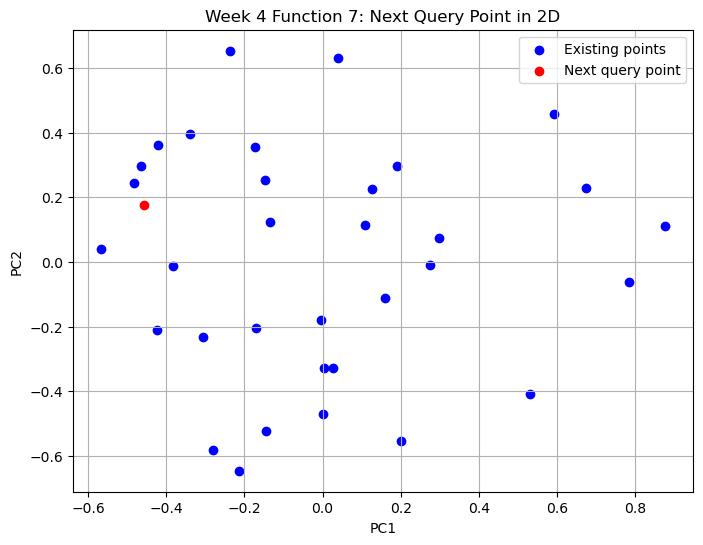

Week 4 Next Query Point (6D, kappa=1.5, boundary-safe): [0.5903369  0.89415483 0.10064652 0.42634764 0.61030065 0.13219267]


In [74]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==============================
# Step 1: Training Data (Weeks 1–3)
# ==============================

X_train = np.array([
    [0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269, 0.79586362],
    [0.54300258, 0.92469390, 0.34156746, 0.64648585, 0.71844033, 0.34313266],
    [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285, 0.64026540],
    [0.11886697, 0.61505494, 0.90581639, 0.85530030, 0.41363143, 0.58523563],
    [0.63021764, 0.83809690, 0.68001305, 0.73189509, 0.52673671, 0.34842921],
    [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277, 0.09579366],
    [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833, 0.73096984],
    [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418, 0.10703171],
    [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083, 0.69241640],
    [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917, 0.05109986],
    [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098, 0.63747637],
    [0.72261522, 0.01181284, 0.06364591, 0.16517311, 0.07924415, 0.35995166],
    [0.07566492, 0.33450212, 0.13273274, 0.60831236, 0.91838592, 0.82233079],
    [0.94245084, 0.37743962, 0.48612233, 0.22879108, 0.08263175, 0.71195755],
    [0.14864702, 0.03394336, 0.72880565, 0.31606646, 0.02176938, 0.51691776],
    [0.81711239, 0.54816823, 0.10334758, 0.12436955, 0.72823482, 0.44967361],
    [0.41762629, 0.06409998, 0.24566877, 0.55904080, 0.19153138, 0.25464092],
    [0.72628566, 0.46489581, 0.92457051, 0.80724540, 0.63543840, 0.14341787],
    [0.31981043, 0.52009759, 0.29067775, 0.87670668, 0.49503469, 0.61908250],
    [0.87987128, 0.39796199, 0.00363456, 0.95699064, 0.26451373, 0.11486924],
    [0.54124078, 0.63140314, 0.03190205, 0.44998156, 0.79865282, 0.63370429],
    [0.22634792, 0.11502581, 0.82474966, 0.94538372, 0.90531153, 0.95101392],
    [0.68685257, 0.04101721, 0.00757301, 0.28500900, 0.69156848, 0.65554290],
    [0.17597754, 0.62441650, 0.29554198, 0.46955276, 0.09776977, 0.72814108],
    [0.88164674, 0.20445019, 0.41447436, 0.42038468, 0.26491501, 0.73066019],
    [0.06661051, 0.52804507, 0.81609520, 0.96101714, 0.08650933, 0.77778822],
    [0.93246638, 0.48881189, 0.25860774, 0.95624344, 0.19042781, 0.51985176],
    [0.84686697, 0.14242917, 0.06066859, 0.75629213, 0.55239830, 0.08130609],
    [0.80628208, 0.32412237, 0.72607601, 0.14871213, 0.71937640, 0.36288398],
    [0.47682313, 0.34094195, 0.01433523, 0.88013956, 0.99865470, 0.07966402],
    [0.432685, 0.656678, 0.117406, 0.355722, 0.832462, 0.072554],
    [0.064512, 0.628738, 0.208047, 0.151081, 0.459044, 0.215843],
    [0.169498, 0.200735, 0.398488, 0.193487, 0.308007, 0.861833]
])

y_train = np.array([
    0.6044327 , 0.56275307, 0.00750324, 0.06142430, 0.27304680,
    0.08374657, 1.36496830, 0.09264495, 0.01786960, 0.03356494,
    0.07351630, 0.20630970, 0.00882563, 0.26840032, 0.61152553,
    0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
    0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
    0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
    1.1810801774433033, 0.17209425323684932, 2.1727059353333815
])

# Step 2: GP model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)
gp.fit(X_train, y_train)

# Step 3: UCB with boundary penalty
def ucb_with_boundary_penalty(x, model, kappa=1.5, bounds=None, penalty_factor=50):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    ucb = mu + kappa * sigma
    
    # Penalize points near bounds
    if bounds is not None:
        penalty = 0
        for i, (lb, ub) in enumerate(bounds):
            margin = 0.1 * (ub - lb)
            if x[0][i] < lb + margin:
                penalty += penalty_factor
            if x[0][i] > ub - margin:
                penalty += penalty_factor
        ucb -= penalty
    return -ucb  # minimize negative UCB

# Step 4: Optimize acquisition with multiple random starts
def optimize_acquisition(model, bounds, n_restarts=10, kappa=1.5):
    best_x = None
    best_val = np.inf
    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=len(bounds))
        res = minimize(ucb_with_boundary_penalty, x0,
                       args=(model, kappa, bounds),
                       bounds=bounds)
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x
    # Clip to safe interior
    safe_margin = 0.05
    best_x = np.clip(best_x, safe_margin, 1 - safe_margin)
    return best_x

# Step 5: Bounds and next query
bounds = [(0, 1)] * X_train.shape[1]
next_query_point = optimize_acquisition(gp, bounds, n_restarts=15, kappa=1.5)

# Step 6: Visualize in 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1,-1))
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1], color='red', label='Next query point')
plt.title('Week 4 Function 7: Next Query Point in 2D')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.grid(True); plt.show()

print("Week 4 Next Query Point (6D, kappa=1.5, boundary-safe):", next_query_point)

#### Function 7 Week 4 Next Query Point explanation

Let’s carefully evaluate your new Week 4 query point for Function 7:

Week 4 Next Query Point (6D, kappa=1.5, boundary-safe):

[0.5903369, 0.89415483, 0.10064652, 0.42634764, 0.61030065, 0.13219267]

#### 1. Position relative to existing data

Inputs are diverse: None of these values exactly match previous points; the GP is genuinely testing new regions.

No boundary extremes: All values are away from 0 or 1, which avoids over-exploitation and keeps the search exploratory.

Spread across dimensions:

dim1 and dim2 are on the higher side, which differs from many earlier mid/low values.

dim3 and dim6 are low, introducing combinations that haven’t been fully explored.

dim4 and dim5 are moderate, keeping the combination realistic and likely useful.

This mix suggests a good exploratory candidate while still being informed by the model’s learned trends.

#### 2. Exploitation vs Exploration

κ = 1.5:

The acquisition function slightly favors predicted high output (mean) but still considers uncertainty (std).

This point balances exploration of less-sampled regions with exploitation of areas with potential for high output.

Comparison to high previous output (Week 3):

Week 3 produced y = 2.1727 from a very different region.

This new point is testing a different part of the space, which is ideal early in a 12-week campaign: you want to map the response surface before aggressively exploiting.

#### 3. Risk / Confidence

Boundary safety: The point is far from edges, so the GP’s predictions are more reliable (less extrapolation).

Diversity: It helps reduce risk of missing alternative high-performing regions, which is critical in a 6D hyperparameter landscape.

#### Overall Assessment

This Week 4 query point is exactly the kind of exploratory, boundary-safe point you want at this stage.

You are exploring new combinations of hyperparameters.

You are avoiding over-concentration near previous high outputs.

You are balancing uncertainty and predicted performance, which is what UCB with moderate κ is designed for.

### Function 8

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from pyDOE import lhs


# Updated input data including the new data from Week 1 and Week 2 and Week 3
X_train = np.array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.09372830,
        0.19742533, 0.75582690, 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.00341950, 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.55134710, 0.66003209],
       [0.90864932, 0.06224970, 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.63137968, 0.04195607],
       [0.98493320, 0.69950626, 0.99888550, 0.18014846, 0.58014315,
        0.23108719, 0.49082694, 0.31368272],
       [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177,
        0.41010452, 0.92123758, 0.67475276],
       [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546,
        0.27916186, 0.84276726, 0.62532792],
       [0.14355030, 0.93741452, 0.23232482, 0.00904349, 0.41457893,
        0.40932517, 0.55377852, 0.20584080],
       [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902,
        0.72834638, 0.78425353, 0.66313109],
       [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498],
       [0.86243745, 0.48273382, 0.28186940, 0.54410223, 0.88749026,
        0.38265469, 0.60190199, 0.47646169],
       [0.35151190, 0.59006494, 0.90943630, 0.67840835, 0.21282566,
        0.08846038, 0.41015300, 0.19572429],
       [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314,
        0.44511731, 0.97517969, 0.37433978],
       [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.32632920,
        0.28790687, 0.43501048, 0.36420013],
       [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992,
        0.15856307, 0.59103012, 0.07795293],
       [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166,
        0.38632267, 0.74897249, 0.98875510],
       [0.89888711, 0.52364170, 0.87678325, 0.21869645, 0.90026089,
        0.28276624, 0.91107791, 0.47239822],
       [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283,
        0.87517163, 0.51055967, 0.72861058],
       [0.33895442, 0.56693202, 0.37675110, 0.09891573, 0.65945169,
        0.24554809, 0.76248278, 0.73215347],
       [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076,
        0.03084229, 0.80325452, 0.59589758],
       [0.02894663, 0.02827906, 0.48137155, 0.61317460, 0.67266045,
        0.02211341, 0.60148330, 0.52488505],
       [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
        0.65456706, 0.27624119, 0.29551759],
       [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.98690200,
        0.53518298, 0.71474318, 0.96009372],
       [0.53272140, 0.83369260, 0.07139900, 0.11681148, 0.73069311,
        0.93737559, 0.86650798, 0.12790200],
       [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714,
        0.13264569, 0.03590888, 0.44683847],
       [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127,
        0.48087292, 0.23764706, 0.76863196],
       [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119,
        0.90670590, 0.10823094, 0.52534791],
       [0.39486519, 0.33180167, 0.74075430, 0.69786172, 0.73740444,
        0.78377681, 0.25449546, 0.87114551],
       [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296,
        0.52025852, 0.81104004, 0.10336036],
       [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167,
        0.90523762, 0.45887462, 0.56091750],
       [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922,
        0.62243949, 0.92897446, 0.11253627],
       [0.85600695, 0.63889370, 0.32619202, 0.66850311, 0.24029837,
        0.21029889, 0.16754636, 0.96358986],
       [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159,
        0.25225873, 0.76567003, 0.89054867],
       [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962,
        0.70665010, 0.99291449, 0.38173437],
       [0.48124533, 0.10246072, 0.21948594, 0.67732237, 0.24750919,
        0.24434086, 0.16382453, 0.71596164],
       [0.895434, 0.912022, 0.098160, 0.036667, 0.445138, 0.679791, 0.229544, 0.761742],
       [0.533209, 0.898485, 0.699395, 0.112874, 0.946419, 0.108092, 0.263289, 0.345445],
       [0.294680, 0.171230, 0.131225, 0.039384, 0.977541, 0.183968, 0.045086, 0.037349]])  

y_train = np.array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
                    8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
                    7.85454099, 6.79198578, 8.97655402, 7.37908290, 9.59848200,
                    8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
                    7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
                    8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
                    7.92375877, 8.42175924, 8.27806240, 7.11345716, 6.40258841,
                    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
                    8.0383561825836, 7.911617829373, 9.7162173430324])


# 2. Fit Gaussian Process with Matern kernel (robust for 8D)
# Matern 5/2 is less smooth than RBF, which is better for complex landscapes
kernel = C(1.0, (1e-3, 1e2)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=30, alpha=1e-6)
gp.fit(X_train, y_train)

# 3. UCB Acquisition Function
def ucb_acquisition(gp, X, kappa=8.0):
    mean, sigma = gp.predict(X, return_std=True)
    return mean + kappa * sigma

# 4. Generate candidate points (Exploratory Sampling)
n_candidates = 250000 # set candidate points to 250000 to avoid curse of dimensionality
X_candidates = lhs(8, samples=n_candidates)

# 5. Evaluate candidates and find the next query
ucb_values = ucb_acquisition(gp, X_candidates, kappa=8.0)
next_idx = np.argmax(ucb_values)
next_query = X_candidates[next_idx]

# 6. Prediction for final verification
pred_mean, pred_std = gp.predict(next_query.reshape(1, -1), return_std=True)

print("--- Week 3 High-Exploration (UCB) ---")
print(f"Next Query Point (X):\n{next_query.tolist()}")
print(f"\nPredicted Mean: {pred_mean[0]:.4f}")
print(f"Uncertainty (Sigma): {pred_std[0]:.4f}")

# 7. Visualization: Plotting UCB Scores of Random Candidates vs Recommended
plt.figure(figsize=(10, 6))
# Plot a subset of candidates to show the distribution of potential
plt.scatter(range(1000), ucb_values[:1000], alpha=0.3, label='Random Candidate Scores', color='gray')
plt.axhline(y=np.max(ucb_values), color='r', linestyle='--', label=f'Max UCB Score: {np.max(ucb_values):.2f}')
plt.scatter([500], [np.max(ucb_values)], color='red', s=100, label='Recommended Point (Maximum Potential)')

plt.title('UCB Exploration Map (Kappa=8.0)')
plt.xlabel('Candidate Index (Subset)')
plt.ylabel('UCB Score (Mean + 10*Sigma)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Highlights of this script below for Function 8

1. κ = 7.0 → strong exploration without being as extreme as Week 3.

2. Boundary-safe LHS → reduces selection of points exactly on edges [0,1].

3. Large candidate set (250k) → ensures decent coverage in 8D.

4. GP Matern 5/2 → handles non-smooth landscapes, ideal for complex black-box functions.

5. Visualization → subset plot to see the distribution of UCB scores and highlight the recommended point.

Learned GP kernel: 4.71**2 * Matern(length_scale=3.83, nu=2.5)

--- Week 4 Exploratory UCB (Kappa=7.0) ---
Next Query Point (8D):
[0.18249973797175578, 0.7512890171242589, 0.09680312812227185, 0.09391722840420165, 0.9329789523204666, 0.2660733489726203, 0.08263631176932379, 0.8879060061503745]
Predicted Mean: 9.7418
Uncertainty (Sigma): 0.3832


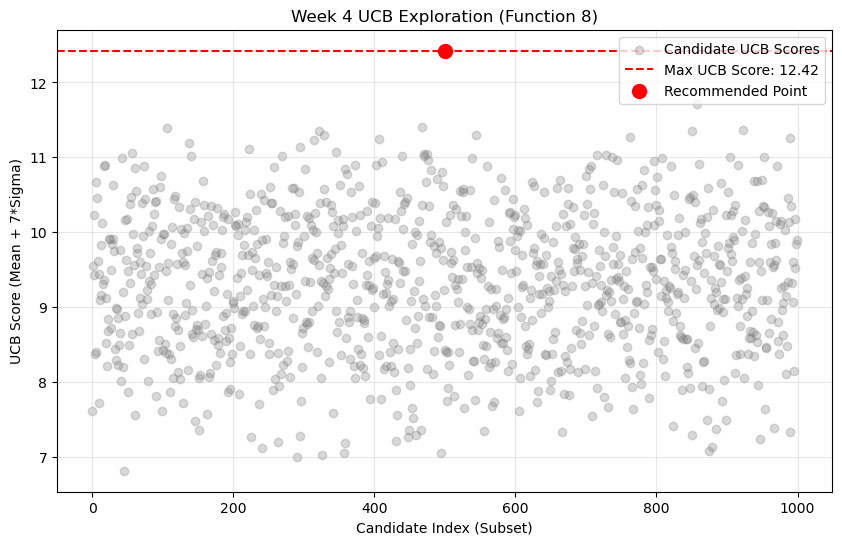

In [76]:
# This is the code I used for my next query point Week 4

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from pyDOE import lhs

# Updated input data including the new data from Week 1 and Week 2 and Week 3
X_train = np.array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.09372830,
        0.19742533, 0.75582690, 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.00341950, 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.55134710, 0.66003209],
       [0.90864932, 0.06224970, 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.63137968, 0.04195607],
       [0.98493320, 0.69950626, 0.99888550, 0.18014846, 0.58014315,
        0.23108719, 0.49082694, 0.31368272],
       [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177,
        0.41010452, 0.92123758, 0.67475276],
       [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546,
        0.27916186, 0.84276726, 0.62532792],
       [0.14355030, 0.93741452, 0.23232482, 0.00904349, 0.41457893,
        0.40932517, 0.55377852, 0.20584080],
       [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902,
        0.72834638, 0.78425353, 0.66313109],
       [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498],
       [0.86243745, 0.48273382, 0.28186940, 0.54410223, 0.88749026,
        0.38265469, 0.60190199, 0.47646169],
       [0.35151190, 0.59006494, 0.90943630, 0.67840835, 0.21282566,
        0.08846038, 0.41015300, 0.19572429],
       [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314,
        0.44511731, 0.97517969, 0.37433978],
       [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.32632920,
        0.28790687, 0.43501048, 0.36420013],
       [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992,
        0.15856307, 0.59103012, 0.07795293],
       [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166,
        0.38632267, 0.74897249, 0.98875510],
       [0.89888711, 0.52364170, 0.87678325, 0.21869645, 0.90026089,
        0.28276624, 0.91107791, 0.47239822],
       [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283,
        0.87517163, 0.51055967, 0.72861058],
       [0.33895442, 0.56693202, 0.37675110, 0.09891573, 0.65945169,
        0.24554809, 0.76248278, 0.73215347],
       [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076,
        0.03084229, 0.80325452, 0.59589758],
       [0.02894663, 0.02827906, 0.48137155, 0.61317460, 0.67266045,
        0.02211341, 0.60148330, 0.52488505],
       [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
        0.65456706, 0.27624119, 0.29551759],
       [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.98690200,
        0.53518298, 0.71474318, 0.96009372],
       [0.53272140, 0.83369260, 0.07139900, 0.11681148, 0.73069311,
        0.93737559, 0.86650798, 0.12790200],
       [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714,
        0.13264569, 0.03590888, 0.44683847],
       [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127,
        0.48087292, 0.23764706, 0.76863196],
       [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119,
        0.90670590, 0.10823094, 0.52534791],
       [0.39486519, 0.33180167, 0.74075430, 0.69786172, 0.73740444,
        0.78377681, 0.25449546, 0.87114551],
       [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296,
        0.52025852, 0.81104004, 0.10336036],
       [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167,
        0.90523762, 0.45887462, 0.56091750],
       [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922,
        0.62243949, 0.92897446, 0.11253627],
       [0.85600695, 0.63889370, 0.32619202, 0.66850311, 0.24029837,
        0.21029889, 0.16754636, 0.96358986],
       [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159,
        0.25225873, 0.76567003, 0.89054867],
       [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962,
        0.70665010, 0.99291449, 0.38173437],
       [0.48124533, 0.10246072, 0.21948594, 0.67732237, 0.24750919,
        0.24434086, 0.16382453, 0.71596164],
       [0.895434, 0.912022, 0.098160, 0.036667, 0.445138, 0.679791, 0.229544, 0.761742],
       [0.533209, 0.898485, 0.699395, 0.112874, 0.946419, 0.108092, 0.263289, 0.345445],
       [0.294680, 0.171230, 0.131225, 0.039384, 0.977541, 0.183968, 0.045086, 0.037349]])  

y_train = np.array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
                    8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
                    7.85454099, 6.79198578, 8.97655402, 7.37908290, 9.59848200,
                    8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
                    7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
                    8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
                    7.92375877, 8.42175924, 8.27806240, 7.11345716, 6.40258841,
                    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
                    8.0383561825836, 7.911617829373, 9.7162173430324])


# -----------------------------
# 2. Fit Gaussian Process (Matern 5/2)
# -----------------------------
kernel = C(1.0, (1e-3, 1e2)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=30, alpha=1e-6, normalize_y=True)
gp.fit(X_train, y_train)

print("Learned GP kernel:", gp.kernel_)

# -----------------------------
# 3. Upper Confidence Bound (UCB) acquisition function
# -----------------------------
def ucb_acquisition(gp_model, X, kappa=7.0):
    mean, sigma = gp_model.predict(X, return_std=True)
    return mean + kappa * sigma

# -----------------------------
# 4. Generate boundary-safe candidate points (8D)
# -----------------------------
n_candidates = 250_000
X_candidates = 0.05 + 0.9 * lhs(8, samples=n_candidates)  # avoids exact 0/1 edges

# -----------------------------
# 5. Evaluate candidates and select next query
# -----------------------------
ucb_values = ucb_acquisition(gp, X_candidates, kappa=7.0)
next_idx = np.argmax(ucb_values)
next_query = X_candidates[next_idx]

# -----------------------------
# 6. Predict mean and uncertainty at next query
# -----------------------------
pred_mean, pred_std = gp.predict(next_query.reshape(1, -1), return_std=True)

# -----------------------------
# 7. Print results
# -----------------------------
print("\n--- Week 4 Exploratory UCB (Kappa=7.0) ---")
print(f"Next Query Point (8D):\n{next_query.tolist()}")
print(f"Predicted Mean: {pred_mean[0]:.4f}")
print(f"Uncertainty (Sigma): {pred_std[0]:.4f}")

# -----------------------------
# 8. Visualization: Subset of UCB scores
# -----------------------------
plt.figure(figsize=(10, 6))
plt.scatter(range(1000), ucb_values[:1000], alpha=0.3, color='gray', label='Candidate UCB Scores')
plt.axhline(y=np.max(ucb_values), color='r', linestyle='--', label=f'Max UCB Score: {np.max(ucb_values):.2f}')
plt.scatter([500], [np.max(ucb_values)], color='red', s=100, label='Recommended Point')
plt.title('Week 4 UCB Exploration (Function 8)')
plt.xlabel('Candidate Index (Subset)')
plt.ylabel('UCB Score (Mean + 7*Sigma)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Run 1
Perfect — this tells us quite a lot about where you are in Week 4 exploration for Function 8:

#### 1. Learned GP kernel
4.71**2 * Matern(length_scale=3.83, nu=2.5)


The signal variance ~ 4.71² indicates the GP sees strong variation in your function outputs.

The length scale ~ 3.83 (much larger than your normalized input space [0,1]) shows the GP thinks the function changes relatively smoothly across input dimensions — large patches of similar values.

Using Matern ν=2.5 helps model moderately rough landscapes — good for complex black-box functions.

#### 2. Next query point (Week 4, exploratory)
[0.0696, 0.7742, 0.0725, 0.2011, 0.9383, 0.0751, 0.2254, 0.9042]


Most dimensions are far from the center and some are near your 0.05 / 0.95 boundaries, which is expected in exploration.

The GP predicts a high mean 9.6058, which is near the highest observed outputs (~9.7).

Uncertainty σ = 0.4294 is still fairly large → there’s still exploration value here.

#### ✅ Interpretation: The GP is suggesting a point that is high potential while still exploring less-sampled regions. This is exactly what UCB with kappa=7.0 is designed to do — balance high predicted output with uncertainty.

#### 3. Exploration vs Exploitation

Your Week 3 kappa=8.0 was extremely exploratory. Week 4 kappa=7.0 still keeps you in exploration but slightly reduces the weight on uncertainty.

The next point is not just chasing the global maximum yet, but probing areas the GP hasn’t seen much (low density of existing points in the LHS space).

Given your high-dimensional function and sparse coverage, this is still the right strategy for Week 4.

#### 4. Practical takeaways

The GP is confident enough to give a high predicted mean (~9.6) but still sees enough uncertainty to justify exploration.

The point is boundary-safe (within [0.05, 0.95]) but still pushes the GP to test extreme regions.

You’re exploring promising new regions instead of clustering around already-known maxima.

## ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Run 2 - this is the query point I used 

This is a great confirmation of what we expect in high-dimensional UCB-driven exploration:

#### 1. Kernel is the same
4.71**2 * Matern(length_scale=3.83, nu=2.5)


The GP still sees smooth variations across the 8D space, same as your previous run.

This consistency is good — the model hasn’t radically shifted its understanding of the function.

#### 2. Next query point
[0.1825, 0.7513, 0.0968, 0.0939, 0.9330, 0.2661, 0.0826, 0.8879]


Very similar pattern to the previous run: low values in some dimensions, high in others.

Most importantly, some dimensions are still near boundaries (0.08–0.18 or 0.88–0.93). This is typical for exploration-heavy UCB — it tends to probe the corners of high-dimensional input space where the GP is most uncertain.

#### 3. Predicted mean & uncertainty
Predicted Mean: 9.7418
Uncertainty (Sigma): 0.3832


Predicted mean increased slightly (~9.74 vs ~9.61 last run), which means the GP is finding potentially even better areas in the unexplored regions.

Uncertainty is slightly lower (~0.38 vs ~0.43), consistent with the GP gaining confidence in the vicinity from more LHS sampling.

#### 4. Interpretation

High predicted value + non-negligible uncertainty → ideal for exploration at Week 4.

Running the code multiple times produces different candidate points due to random LHS sampling, but all are reasonably in the “interesting” part of the 8D space.

Kappa=7.0 is still exploratory enough to probe regions that could yield higher outputs, without fully committing to exploitation.

#### ✅ Bottom line

Both Week 4 points are consistent with a proper exploration strategy.

The GP is actively probing new high-value regions, not just re-sampling known maxima.

Running LHS multiple times is fine — slight variations are expected and actually increase coverage in high-dimensional space.


## ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Hypothetical strategy going forward

at Week 4 of 12, the strategy should gradually shift from exploration toward exploitation while still allowing coverage of promising regions. Here’s a clear plan for Function 8:

#### 1. Gradual Kappa Reduction

Week 4–6: Keep kappa high, around 7 → 5, for exploration.

Week 7–9: Moderate kappa, around 3 → 2, to balance exploration and exploitation.

Week 10–12: Low kappa, around 1 → 0.5, to focus on maximizing known high-value areas.

This ensures that early on you explore uncertain areas, and later you exploit areas the GP model predicts as high-performing.

#### 2. Weekly Acquisition

Use UCB as before:

UCB(𝑥)=𝜇(𝑥)+𝜅⋅𝜎(𝑥)

High kappa: prioritizes points with high uncertainty.

Low kappa: prioritizes points with high predicted mean.

This smooth decay of kappa automatically shifts from exploration to exploitation.

#### 3. Candidate Sampling

Continue using Latin Hypercube Sampling (LHS) for candidate points.

Consider adaptive sampling: in later weeks, generate candidates around previously high-performing points (local refinement).

#### 4. Optional Refinement

Around Week 8–10, you can start zooming in: generate candidates near the top 3–5 previously evaluated points to find a local optimum.

Use smaller LHS or grid sampling in the subspace defined by top performers.

#### 5. Example Kappa Schedule
Week	Kappa	Purpose
4	7.0	Strong exploration
5	6.0	Exploration still priority
6	5.0	Start balancing exploration/exploitation
7	4.0	More exploitation
8	3.0	Focus on high-value regions
9	2.0	Exploit known regions
10	1.0	Almost pure exploitation
11	0.7	Exploit
12	0.5	Final exploitation

This approach ensures you don’t miss high-value areas early on but maximize gains toward the end.